In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

In [4]:
df = df.drop(['class','who', 'adult_male', 'deck', 'embark_town','alive'],axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [7]:
num_col = ['pclass', 'age', 'sibsp','parch','fare']
cat_col = ['sex','embarked','alone']

In [8]:
X = df.drop('survived', axis=1)
y = df['survived']

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [10]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', SimpleImputer())
])

In [13]:
cat_transfromer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_transfromer,cat_col),
    ('num', num_transformer,num_col)
])

In [16]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preporcessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [18]:
model.fit(X_train,y_train)

,steps,"[('preporcessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score,classification_report
print('Accuracy', accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [23]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[90 15]
 [20 54]]


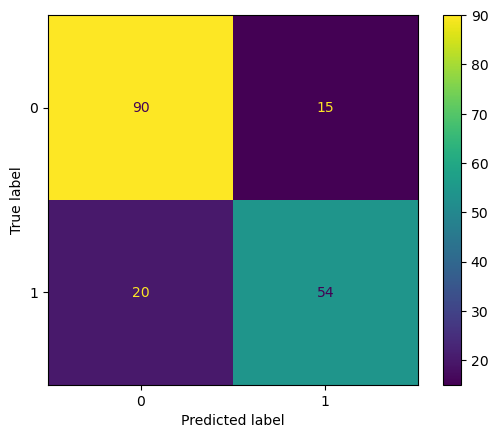

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores.mean())

0.7901450003138535
